### Importing the Libraries

In [131]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn 
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

### Load the Dataset 

In [133]:
data1 = pd.read_csv("Salary Dataset.csv")

### Info of the dataset

In [135]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    int64  
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 17.6+ KB


### Removing the Gender Column from Dataset because it is not important and of no use 

In [137]:
data1 = data1.drop('Gender', axis=1)

### Checking the null values of the Dataset 

In [139]:
data1.isnull().sum()

Age                    0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

### Dropping the all null values which are present in the dataset 

In [141]:
data1 = data1.dropna()

### Again, Checking the null values just to check whether they are removed or not 

In [143]:
data1.isnull().sum()

Age                    0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

### Description of the Dataset 

In [145]:
data1.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100670.241287
std,7.069073,6.557007,48079.583434
min,23.000000,0.000000,30000.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


### head() - prints the first 5 rows and columns of the dataset 

In [147]:
data1.head()

,Age,Education Level,Job Title,Years of Experience,Salary
0,25,Bachelor's,Sales Representative,0.0,30000
1,29,Bachelor's,Junior Business Operations Analyst,1.5,35000
2,25,Bachelor's,Data Entry Clerk,0.0,35000
3,25,Bachelor's,Help Desk Analyst,0.0,35000
4,26,Bachelor's,Junior Accountant,1.0,35000


### we apply one-hot encoding to the entire feature dataset. This converts all categorical variables into numerical (0/1) format.

In [149]:
data1 = pd.get_dummies(data1, columns=["Education Level", "Job Title"], drop_first=True, dtype=int)

In [150]:
data1

,Age,Years of Experience,Salary,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,Job Title_Business Intelligence Analyst,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,25,0.0,30000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,29,1.5,35000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,25,0.0,35000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,25,0.0,35000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,26,1.0,35000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,52,20.0,200000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
369,47,19.0,200000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
370,44,16.0,220000,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
371,50,25.0,250000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### y contains the all Targets value of Dataset

In [152]:
y = data1["Salary"]

### In x, first we will remove the target row from dataset and then x will be having all features of the Dataset 

In [154]:
x = data1.drop("Salary", axis=1)

### Printing all Targets value of the Datatset

In [156]:
y

0       30000
1       35000
2       35000
3       35000
4       35000
        ...  
368    200000
369    200000
370    220000
371    250000
372    250000
Name: Salary, Length: 373, dtype: int64

### Printing all the features of the Dataset 

In [158]:
x

,Age,Years of Experience,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,Job Title_Business Intelligence Analyst,Job Title_CEO,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,25,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,29,1.5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,25,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,25,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,26,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,52,20.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
369,47,19.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
370,44,16.0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
371,50,25.0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### Now, we apply feature scaling using StandardScaler to normalize the input features.

In [160]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

### Checking shape of the x after scaling the features

In [162]:
x_scaled.shape

(373, 177)

### The dataset is split into training (80%) and testing (20%) sets. The training set is used to train the model, while the testing set is used to evaluate its performance with Predicted data of the Model.

In [164]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=0)

# Linear Regression 

### Creating a Model

In [167]:
model_lr = LinearRegression()

### Training the model by giving them training dataset - x_train and y_train

In [169]:
model_lr.fit(x_train, y_train)

LinearRegression()

### y_pred_lr contains the predicated values of the model which has been predicate after training the model by x_test 

In [171]:
y_pred_lr = model_lr.predict(x_test)
print(y_pred_lr)

[ 4.60960000e+04  1.52336000e+05  6.23511488e+18  9.77520000e+04
  1.07360000e+05  6.10720000e+04  1.14728000e+05  3.61680000e+04
  8.55360000e+04  1.20936000e+05  1.29416000e+05  1.84016000e+05
  6.77591099e+18  1.27372535e+19  6.03680000e+04  1.35544000e+05
  8.46080000e+04  1.01528000e+05  9.83280000e+04  9.43600000e+04
  2.48412740e+18  1.30352000e+05  1.14032000e+05  1.71456000e+05
 -1.51690619e+19  1.64760000e+05  1.56913447e+18  7.80960000e+04
  2.49120000e+04  3.24320000e+04  1.86717500e+19  1.54754733e+18
  2.02901990e+19  1.10664000e+05  1.42796108e+18  1.43968000e+05
  4.18800000e+04  3.04416107e+18  4.97845175e+18  1.56913447e+18
  4.36560000e+04  8.27312145e+18 -2.56630047e+19  1.41648000e+05
  9.75120000e+04  2.52960000e+04  1.09425019e+19  6.45280000e+04
  3.06720000e+04  2.23484357e+18  1.41648000e+05  1.12832000e+05
  8.11125121e+17  1.80000000e+05 -2.45732445e+19  1.14096000e+05
  1.14096000e+05  1.54754733e+18  1.29072000e+05  5.63760000e+04
  8.48960000e+04  4.53760

### y_test contains the actual values of the dataset

In [173]:
y_test

45      40000
272    135000
54      45000
236    115000
253    120000
        ...  
56      45000
8       35000
198    100000
308    160000
78      50000
Name: Salary, Length: 75, dtype: int64

### EVALUATION METRICS OF LINEAR REGRESSION 

In [175]:
print("EVALUATION METRICS OF LINEAR REGRESSION : ")
print("Mean Absolute Error = ",mean_absolute_error(y_test,y_pred_lr))
print("Mean Square Error = ",mean_squared_error(y_test,y_pred_lr))
print("R2 Score =",r2_score(y_test,y_pred_lr))

EVALUATION METRICS OF LINEAR REGRESSION : 
Mean Absolute Error =  2.7275814517309727e+18
Mean Square Error =  4.010825075912848e+37
R2 Score = -1.823050746201907e+28


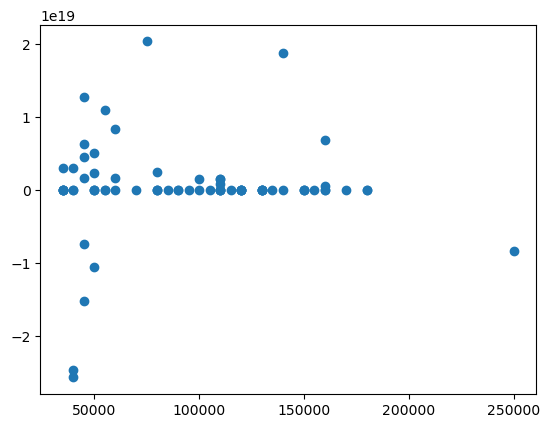

In [176]:
plt.scatter(y_test,y_pred_lr)

# Decision Tree

### Creating a Model

In [179]:
dt_classifier = DecisionTreeClassifier(random_state = 42)

### Training the model by giving the training Dataset - x_train and y_train

In [181]:
dt_classifier.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

### y_pred_dt contains the predicated value which has been gotten after training the model with x_test

In [183]:
y_pred_dt = dt_classifier.predict(x_test)
print(y_pred_dt)

[ 40000 180000  45000  90000 120000  70000 120000  35000  65000 120000
 140000 180000 180000  45000  90000 110000  90000 120000 100000  90000
 120000 130000 110000 170000  50000 160000 120000 120000  40000  35000
 120000 120000  65000 110000 120000 150000  35000  40000  45000  45000
  55000  60000  40000 150000  85000  35000  45000  75000  35000  45000
 150000 105000 140000 180000  40000 120000 120000 130000 140000  60000
  85000  55000 130000  90000  40000  45000 160000 160000 110000 250000
  45000  40000 130000 180000  50000]


### y_test contains the actual values of the dataset

In [185]:
y_test

45      40000
272    135000
54      45000
236    115000
253    120000
        ...  
56      45000
8       35000
198    100000
308    160000
78      50000
Name: Salary, Length: 75, dtype: int64

### EVALUATION METRICS OF DEISION TREE 

In [187]:
print("EVALUATION METRICS OF DECISION TREE : ")
print("Mean Abosulte Error = ",mean_absolute_error(y_test, y_pred_dt))
print("Mean Square Error = ",mean_squared_error(y_test, y_pred_dt))
print("R2 Score = ",r2_score(y_test,y_pred_dt))

EVALUATION METRICS OF DECISION TREE : 
Mean Abosulte Error =  9266.666666666666
Mean Square Error =  251000000.0
R2 Score =  0.8859123176314205


# Random Forest

### Creating a Model 

In [190]:
rf_classifier =RandomForestClassifier(random_state=42)

### Training the model by giving them the training dataset - x_train and y_train 

In [192]:
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

### y_pred_rf contains all predicated values of the dataset which has been got after training the model with x_test

In [194]:
y_pred_rf = rf_classifier.predict(x_test)
y_pred_rf

array([ 40000, 140000,  45000,  90000, 120000,  60000, 120000,  40000,
        65000, 120000, 105000, 180000, 180000,  45000,  75000, 140000,
        80000, 100000, 100000,  90000, 120000, 130000, 110000, 170000,
        40000, 160000, 100000,  90000,  40000,  35000, 120000, 120000,
        65000, 110000, 120000, 150000,  35000,  40000,  45000,  75000,
        50000,  60000,  40000, 150000,  85000,  40000,  45000,  75000,
        40000,  45000, 150000,  90000, 130000, 180000,  40000, 100000,
       100000, 130000, 140000,  60000,  85000,  50000, 130000,  90000,
        40000,  45000, 140000, 160000, 110000, 180000,  45000,  40000,
        95000, 180000,  50000], dtype=int64)

### y_test contains the actual values of the dataset

In [196]:
y_test

45      40000
272    135000
54      45000
236    115000
253    120000
        ...  
56      45000
8       35000
198    100000
308    160000
78      50000
Name: Salary, Length: 75, dtype: int64

### EVALUATION METRICES OF RANDOM FOREST 

In [198]:
print("EVALUATION METRICES OF RANDOM FOREST :" )
print("Mean Absolute Error : ",mean_absolute_error(y_test, y_pred_rf))
print("Mean Square error : ",mean_squared_error(y_test, y_pred_rf))
print("R2 Score = ",r2_score(y_test,y_pred_rf))

EVALUATION METRICES OF RANDOM FOREST :
Mean Absolute Error :  9733.333333333334
Mean Square error :  254000000.0
R2 Score =  0.8845487198341865


# Conclusion

In this, different machine learning regression algorithms were applied on the Salary Prediction Dataset to predict salary based on features such as age, education level, job title, and years of experience.
Before training the models, important preprocessing steps were performed:
* unnecessary columns like Gender were removed,
* missing values were handled,
* categorical variables were converted into numerical form using one-hot encoding.

Three regression algorithms were implemented and compared:

**1. Linear Regression** 

Linear Regression performed very poorly on this dataset.
The model produced extremely large error values and a highly negative R² score, indicating that it failed to capture the relationship between features and salary properly.

This happened because the dataset contains: 
* complex categorical features
* non-linear salary patterns
* multiple job-title relationships

Since, Linear Regression assumes a linear relationship between input features and target values, it was not suitable for this dataset.

**2. Decision Tree Regression**

Decision Tree Regressor performed significantly better.

Results:
* Mean Absolute Error ≈ 9266
* Mean Squared Error ≈ 251000000
* R² Score ≈ 0.886

The model successfully captured non-linear patterns and feature interactions in the dataset. It handled salary variations effectively and provided accurate predictions.

**3. Random Forest Regression**

Random Forest Regressor also performed very well.

Results:

* Mean Absolute Error ≈ 9733
* Mean Squared Error ≈ 254000000
* R² Score ≈ 0.885

The performance was very close to Decision Tree Regression. Random Forest handled the dataset efficiently by combining predictions from multiple decision trees, reducing instability and improving robustness.

**Final Conclusion**

Among all the algorithms tested, Decision Tree and Random Forest Regression performed much better than Linear Regression.

This experiment shows that:

* tree-based algorithms are more suitable for complex and non-linear datasets
* proper preprocessing is essential in machine learning
* model selection depends on dataset characteristics

Overall, Decision Tree and Random Forest proved to be effective algorithms for salary prediction on this dataset.

### Salary vs Experience

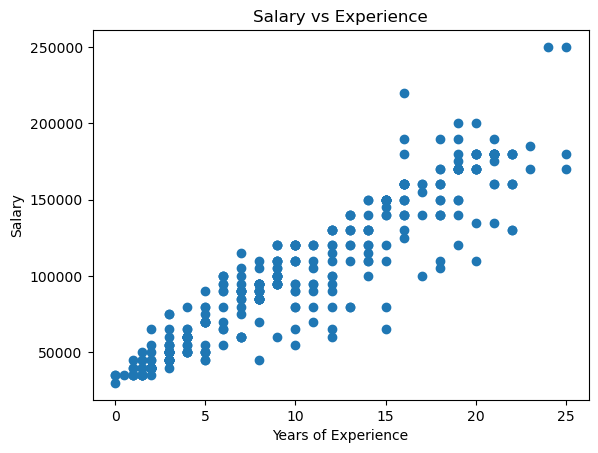

In [206]:
plt.scatter(data1["Years of Experience"], data1["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()

### Correlation Heatmap

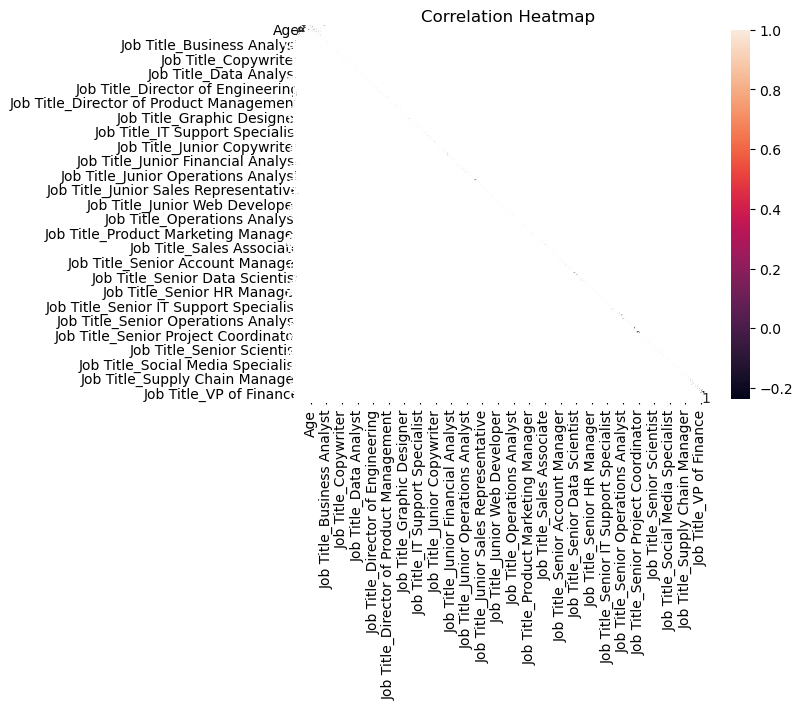

In [208]:
corr = data1.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Graph of Actual Salary vs Predicated Salary of Decision Tree

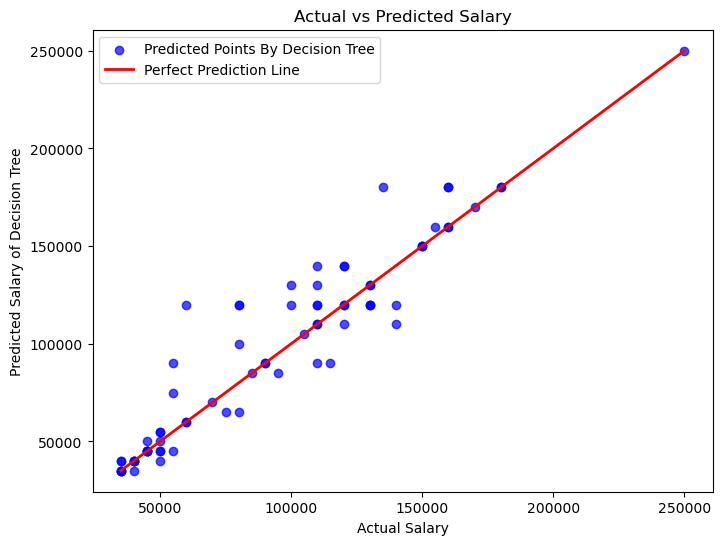

In [210]:
'''#Best Performaing model's Actual Salary and Predicated Salary 
#Decision Tree
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()
'''
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_dt,color='blue',alpha=0.7,label='Predicted Points By Decision Tree')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red',linewidth=2,label='Perfect Prediction Line')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary of Decision Tree")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()